In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
ecom = pd.read_csv('OnlineRetail.csv', encoding='ISO-8859-1')
print("Shape:", ecom.shape)
print("Columns:", ecom.columns.tolist())

Shape: (541909, 8)
Columns: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']


In [3]:
ecom

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France


In [4]:
ecom.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [5]:
ecom.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [6]:
ecom.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [7]:
ecom.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [8]:
ecom.tail()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,12/9/2011 12:50,4.95,12680.0,France


In [9]:
print("Duplicate rows:", ecom.duplicated().sum())

Duplicate rows: 5268


In [10]:
#removing duplicated rows
ecom = ecom.drop_duplicates()

In [11]:
#confirming to see if they have been removed 
print("Rows after removing duplicates:", ecom.shape[0])

Rows after removing duplicates: 536641


In [12]:
# Drop rows where Description is missing
ecom = ecom.dropna(subset=['Description'])

In [13]:
# Drop rows where CustomerID is missing
ecom = ecom.dropna(subset=['CustomerID'])

In [14]:
# total rows after removing nulls
print("Rows after handling missing values:", ecom.shape[0])

Rows after handling missing values: 401604


In [15]:
#converting the invoice date from text to datetime
ecom['InvoiceDate'] = pd.to_datetime(ecom['InvoiceDate'])

In [16]:
#converting customer id from float to integer 
ecom['CustomerID'] = ecom['CustomerID'].astype(int)

In [17]:
print(ecom.dtypes)

InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID              int64
Country                object
dtype: object


In [18]:
# to check cancelled tyansactions
cancelled = ecom[ecom['InvoiceNo'].astype(str).str.startswith('C')]
print("Cancelled transactions:", len(cancelled))

Cancelled transactions: 8872


In [19]:
#removing cancelled transactions
ecom = ecom[~ecom['InvoiceNo'].astype(str).str.startswith('C')]
ecom

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680,France


In [20]:
#rows after removing cancellations
print("Rows after removing cancellations:", ecom.shape[0])

Rows after removing cancellations: 392732


In [21]:
# checking for any other negative quantities
print("Negative quantities:", (ecom['Quantity'] <= 0).sum())

Negative quantities: 0


In [22]:
# checking for negative unit prices
print("Zero or negative prices:", (ecom['UnitPrice'] <= 0).sum())

Zero or negative prices: 40


In [23]:
# Removing zero and negative unit prices
ecom = ecom[ecom['UnitPrice'] > 0]
ecom

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680,France


In [24]:
# Confirming how many rows remain
print("Rows after removing invalid prices:", ecom.shape[0])

Rows after removing invalid prices: 392692


In [25]:
print("Missing values:\n", ecom.isnull().sum())
print("\nDuplicates:", ecom.duplicated().sum())
print("\nNegative quantities:", (ecom['Quantity'] <= 0).sum())
print("\nZero or negative prices:", (ecom['UnitPrice'] <= 0).sum())
print("\nFinal shape:", ecom.shape)

Missing values:
 InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

Duplicates: 0

Negative quantities: 0

Zero or negative prices: 0

Final shape: (392692, 8)


In [26]:
ecom.to_csv(r"C:\Users\USER\OneDrive\Desktop\Data Analysis\AnalystLab Africa\Data\Cleaned.csv", index=False)



In [28]:

#adding a new column
ecom['TotalPrice'] = ecom['Quantity'] * ecom['UnitPrice']
ecom

C:\Users\USER\AppData\Local\Temp\ipykernel_14688\3947428784.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ecom['TotalPrice'] = ecom['Quantity'] * ecom['UnitPrice']


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680,France,10.20
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680,France,12.60
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680,France,16.60
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680,France,16.60


In [29]:
print(ecom['TotalPrice'].head())

0    15.30
1    20.34
2    22.00
3    20.34
4    20.34
Name: TotalPrice, dtype: float64


In [30]:
print("Total Revenue:", ecom['TotalPrice'].sum())
print("Average Order Value:", ecom['TotalPrice'].mean())
print("Total Transactions:", ecom['InvoiceNo'].nunique())
print("Total Customers:", ecom['CustomerID'].nunique())
print("Total Products:", ecom['Description'].nunique())
print("Total Countries:", ecom['Country'].nunique())

Total Revenue: 8887208.894000001
Average Order Value: 22.631499735161402
Total Transactions: 18532
Total Customers: 4338
Total Products: 3877
Total Countries: 37


In [31]:
#Visualisations

In [32]:
top_countries = ecom.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False).head(10)
print(top_countries)

Country
United Kingdom    7285024.644
Netherlands        285446.340
EIRE               265262.460
Germany            228678.400
France             208934.310
Australia          138453.810
Spain               61558.560
Switzerland         56443.950
Belgium             41196.340
Sweden              38367.830
Name: TotalPrice, dtype: float64


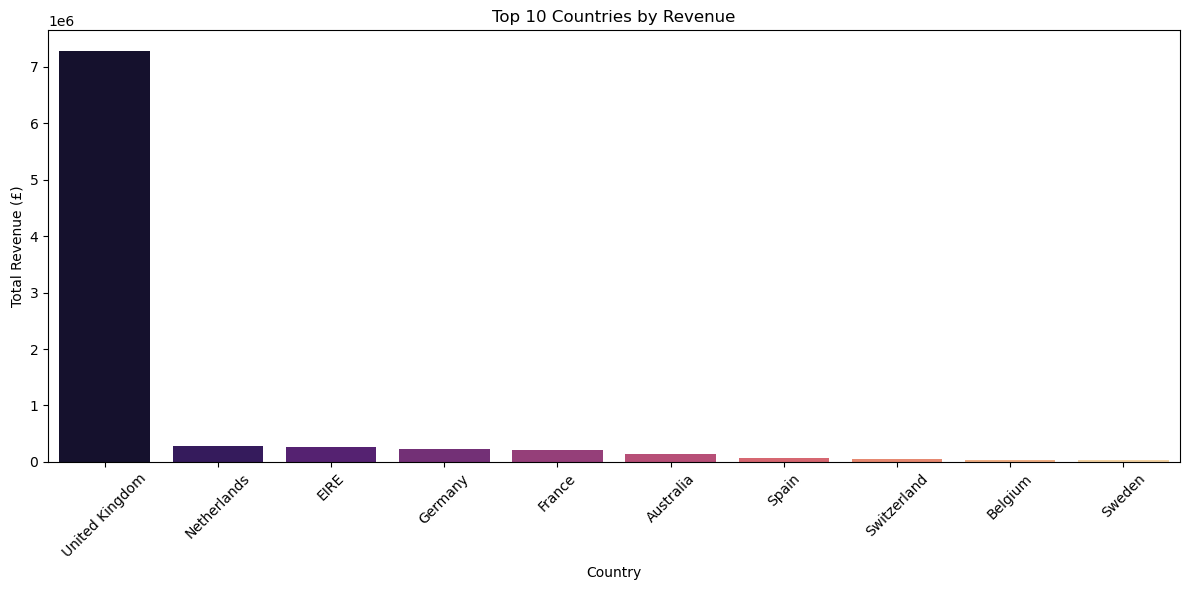

In [33]:
plt.figure(figsize=(12,6))
sns.barplot(x=top_countries.index, y=top_countries.values, hue=top_countries.index, palette='magma', legend=False)
plt.title('Top 10 Countries by Revenue')
plt.xlabel('Country')
plt.ylabel('Total Revenue (£)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [34]:
top_products = ecom.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)
print(top_products)

Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54319
JUMBO BAG RED RETROSPOT               46078
WHITE HANGING HEART T-LIGHT HOLDER    36706
ASSORTED COLOUR BIRD ORNAMENT         35263
PACK OF 72 RETROSPOT CAKE CASES       33670
POPCORN HOLDER                        30919
RABBIT NIGHT LIGHT                    27153
MINI PAINT SET VINTAGE                26076
Name: Quantity, dtype: int64


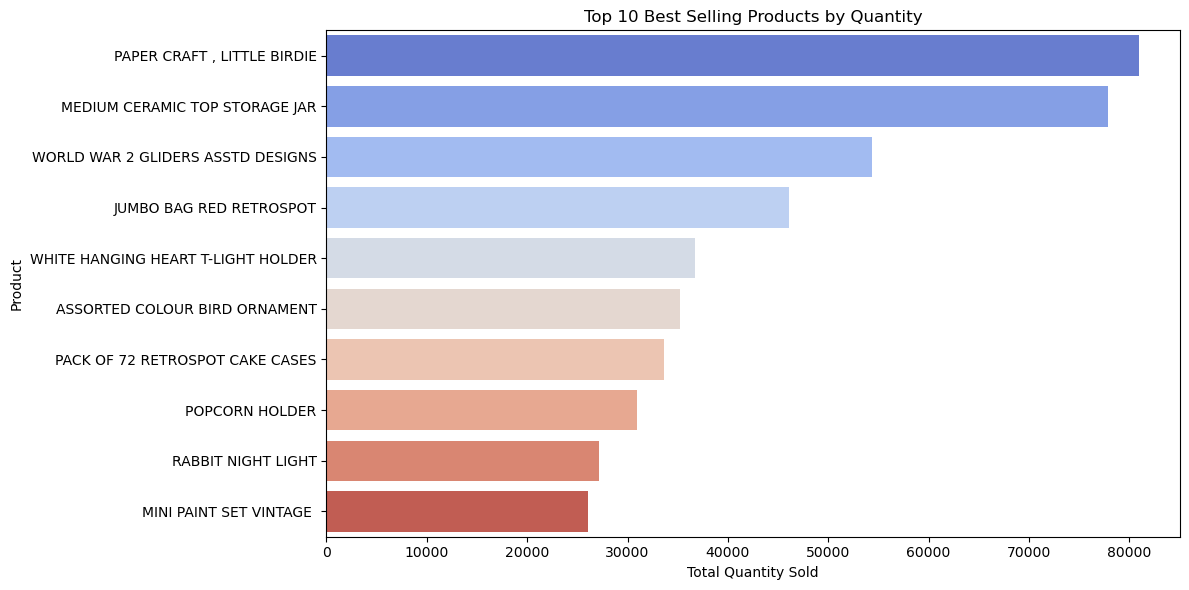

In [35]:
plt.figure(figsize=(12,6))
sns.barplot(x=top_products.values, y=top_products.index, hue=top_products.index, palette='coolwarm', legend=False)
plt.title('Top 10 Best Selling Products by Quantity')
plt.xlabel('Total Quantity Sold')
plt.ylabel('Product')
plt.tight_layout()
plt.show()

In [36]:
#sales trend overtime
#extracting month
ecom['Month'] = ecom['InvoiceDate'].dt.to_period('M')
monthly_sales = ecom.groupby('Month')['TotalPrice'].sum()
print(monthly_sales)

Month
2010-12     570422.730
2011-01     568101.310
2011-02     446084.920
2011-03     594081.760
2011-04     468374.331
2011-05     677355.150
2011-06     660046.050
2011-07     598962.901
2011-08     644051.040
2011-09     950690.202
2011-10    1035642.450
2011-11    1156205.610
2011-12     517190.440
Freq: M, Name: TotalPrice, dtype: float64


C:\Users\USER\AppData\Local\Temp\ipykernel_14688\3661371283.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ecom['Month'] = ecom['InvoiceDate'].dt.to_period('M')


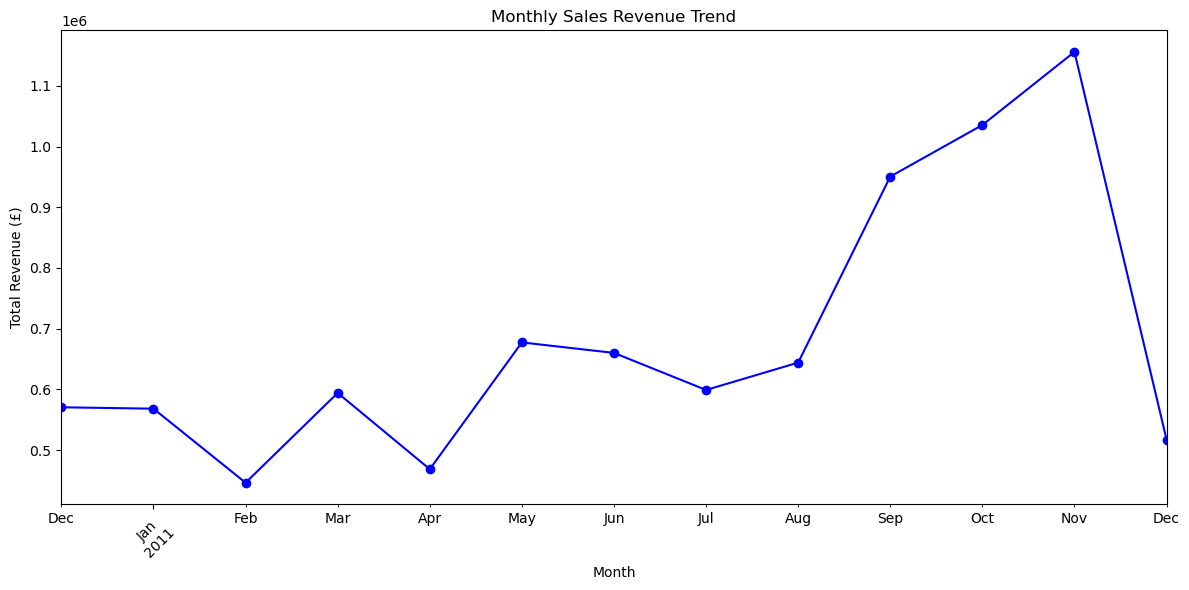

In [37]:
plt.figure(figsize=(12,6))
monthly_sales.plot(kind='line', marker='o', color='blue')
plt.title('Monthly Sales Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Total Revenue (£)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [38]:
#top customers by revenue
top_customers = ecom.groupby('CustomerID')['TotalPrice'].sum().sort_values(ascending=False).head(10)
print(top_customers)

CustomerID
14646    280206.02
18102    259657.30
17450    194390.79
16446    168472.50
14911    143711.17
12415    124914.53
14156    117210.08
17511     91062.38
16029     80850.84
12346     77183.60
Name: TotalPrice, dtype: float64


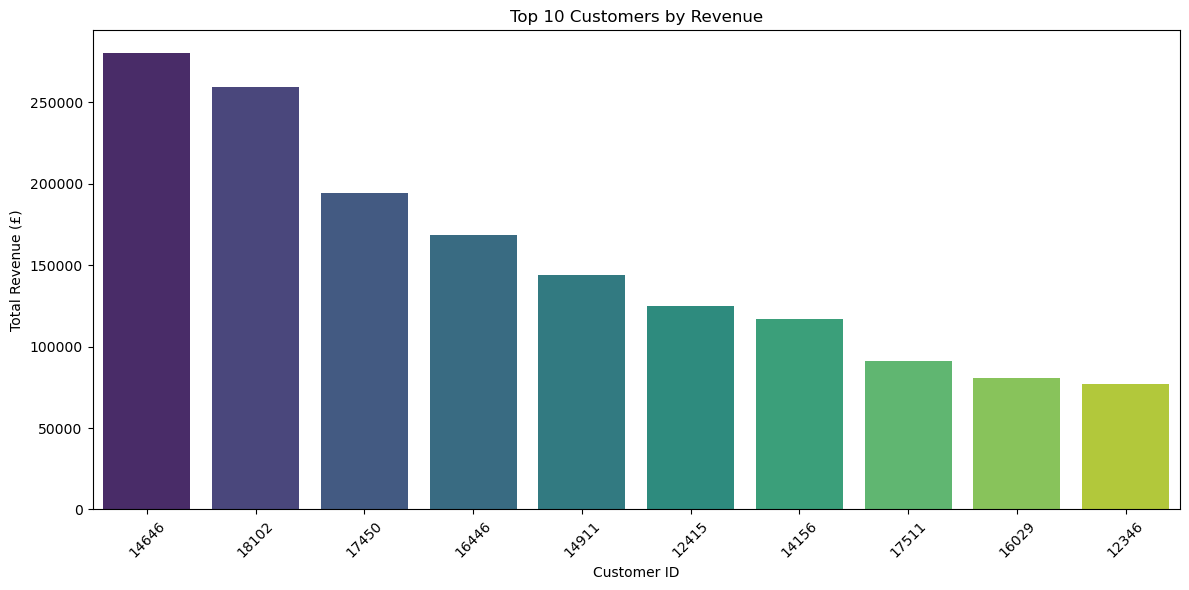

In [39]:
plt.figure(figsize=(12,6))
sns.barplot(x=top_customers.index.astype(str), y=top_customers.values, hue=top_customers.index.astype(str), palette='viridis', legend=False)
plt.title('Top 10 Customers by Revenue')
plt.xlabel('Customer ID')
plt.ylabel('Total Revenue (£)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

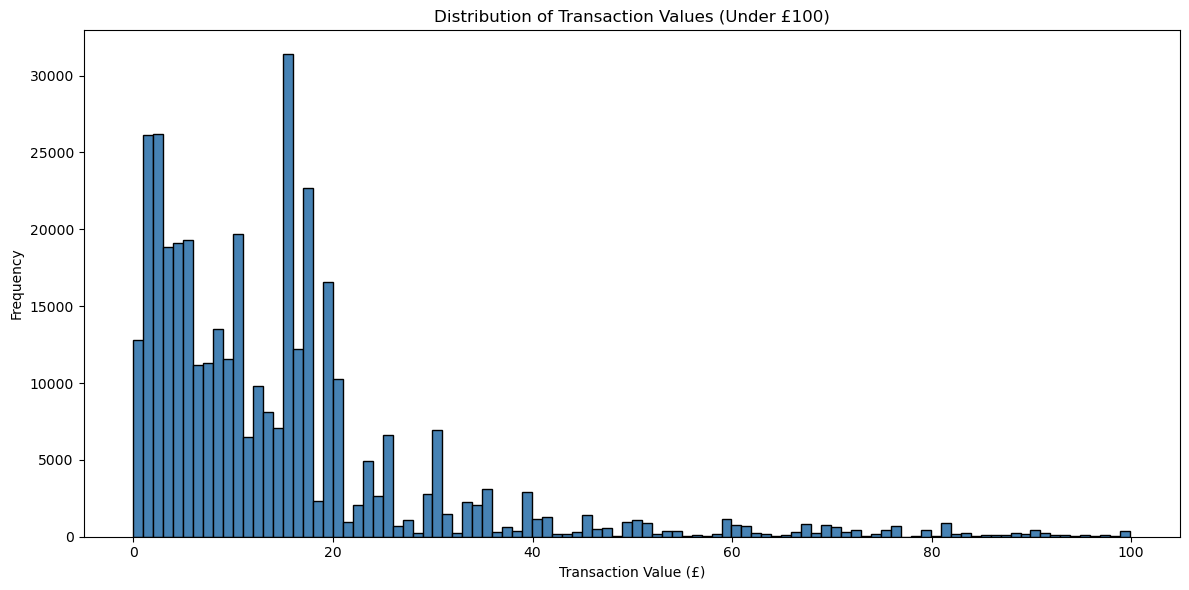

In [40]:
#Revenue Distribution
plt.figure(figsize=(12,6))
plt.hist(ecom[ecom['TotalPrice'] < 100]['TotalPrice'], bins=100, color='steelblue', edgecolor='black')
plt.title('Distribution of Transaction Values (Under £100)')
plt.xlabel('Transaction Value (£)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

## Key Insights

1. UK Market Dominance - The UK accounts for 82% of total revenue (£7,285,025 out of £8,887,208). 
This tells us that the business is heavily dependent on one market.

2. Seasonal Sales Pattern -  Revenue peaked in November 2011 at £1,156,205, which is almost double the average 
monthly revenue. This suggests strong Christmas season demand.

3. Top Product Category - Best selling products are home décor, craft and gift items suggesting that
the business serves a specific niche market.

4. VIP Customer Concentration - The top 10 customers contributed disproportionately large revenue. 
Customer 14646 alone spent £280,206.

5. Low Average Transaction Value - The average order value is £22.63 suggesting the business relies on 
high volume of small purchases rather than big ticket items.